In [1]:
import os
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
)

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("/content")
CLS_PATH = DATA_DIR / "car_evaluation.csv"
REG_PATH = DATA_DIR / "CarPrice_Assignment.csv"

col_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]

def load_car_evaluation(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, header=None, names=col_names, dtype=str)
    for c in df.columns:
        df[c] = df[c].str.strip().str.lower()
    return df

df_cls = load_car_evaluation(CLS_PATH)
print(df_cls.head())
print("Shape:", df_cls.shape)
print("Target distribution:\n", df_cls["class"].value_counts())


  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc
Shape: (1728, 7)
Target distribution:
 class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [2]:
# Фичи и таргет
X_cls = df_cls.drop(columns=["class"])
y_cls = df_cls["class"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_cls
)

print("Train size:", X_train_cls.shape, "| Test size:", X_test_cls.shape)

# Все признаки категориальные
cat_cols_cls = X_train_cls.columns.tolist()

preprocess_cls = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_cls)
    ]
)


Train size: (1382, 6) | Test size: (346, 6)


Датасет небольшой, решающее дерево должно хорошо справиться с такой задачей

In [3]:
gb_clf_base = Pipeline(steps=[
    ("preprocess", preprocess_cls),
    ("model", GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ))
])

gb_clf_base.fit(X_train_cls, y_train_cls)
y_pred_gb_base = gb_clf_base.predict(X_test_cls)

acc_gb_base = accuracy_score(y_test_cls, y_pred_gb_base)
f1_gb_base = f1_score(y_test_cls, y_pred_gb_base, average="macro")

print(f"[GB Classifier — baseline]  Acc={acc_gb_base:.4f} | F1-macro={f1_gb_base:.4f}")
print(classification_report(y_test_cls, y_pred_gb_base))


[GB Classifier — baseline]  Acc=0.9884 | F1-macro=0.9746
              precision    recall  f1-score   support

         acc       0.97      0.97      0.97        77
        good       0.93      1.00      0.97        14
       unacc       1.00      0.99      1.00       242
       vgood       0.93      1.00      0.96        13

    accuracy                           0.99       346
   macro avg       0.96      0.99      0.97       346
weighted avg       0.99      0.99      0.99       346



Найдем оптимиальные параметры гридсерчем

In [4]:
param_grid_gb_clf = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__subsample": [1.0, 0.8],
}

cv_clf_gb = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gb_clf_pipe = Pipeline(steps=[
    ("preprocess", preprocess_cls),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

grid_gb_clf = GridSearchCV(
    gb_clf_pipe,
    param_grid_gb_clf,
    scoring="f1_macro",
    cv=cv_clf_gb,
    n_jobs=-1,
    verbose=1
)

grid_gb_clf.fit(X_train_cls, y_train_cls)

print("Best params (GB classifier):", grid_gb_clf.best_params_)
print("Best CV score (F1-macro):", grid_gb_clf.best_score_)

gb_clf_best = grid_gb_clf.best_estimator_
y_pred_gb_imp = gb_clf_best.predict(X_test_cls)

acc_gb_imp = accuracy_score(y_test_cls, y_pred_gb_imp)
f1_gb_imp = f1_score(y_test_cls, y_pred_gb_imp, average="macro")

print(f"[GB Classifier — improved]  Acc={acc_gb_imp:.4f} | F1-macro={f1_gb_imp:.4f}")
print(classification_report(y_test_cls, y_pred_gb_imp))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best params (GB classifier): {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200, 'model__subsample': 1.0}
Best CV score (F1-macro): 0.9729668191165096
[GB Classifier — improved]  Acc=0.9942 | F1-macro=0.9788
              precision    recall  f1-score   support

         acc       1.00      0.97      0.99        77
        good       0.93      1.00      0.97        14
       unacc       1.00      1.00      1.00       242
       vgood       0.93      1.00      0.96        13

    accuracy                           0.99       346
   macro avg       0.97      0.99      0.98       346
weighted avg       0.99      0.99      0.99       346



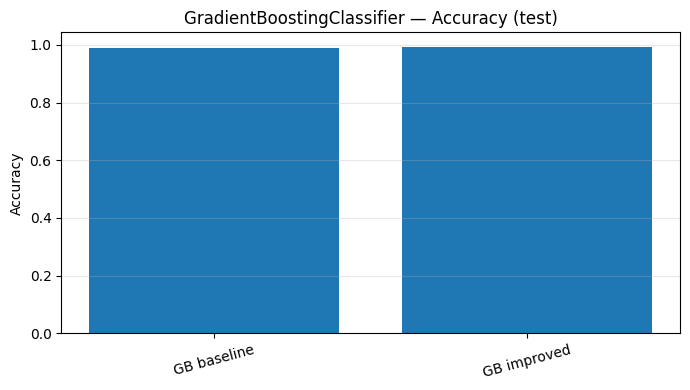

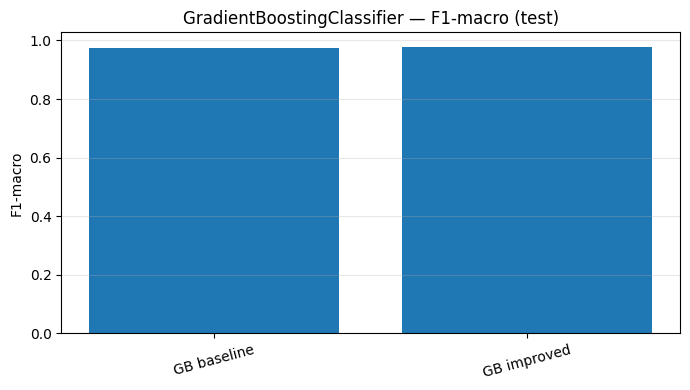

In [5]:
models_cls = ["GB baseline", "GB improved"]

accs = [acc_gb_base, acc_gb_imp]
f1s  = [f1_gb_base, f1_gb_imp]

plt.figure(figsize=(7, 4))
plt.bar(models_cls, accs)
plt.ylabel("Accuracy")
plt.title("GradientBoostingClassifier — Accuracy (test)")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(models_cls, f1s)
plt.ylabel("F1-macro")
plt.title("GradientBoostingClassifier — F1-macro (test)")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# Регрессия

In [3]:
from sklearn.preprocessing import MinMaxScaler

def load_car_price_assignment(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    y = df["price"]
    X = df.drop(columns=["price", "car_ID"])
    # Выделяем бренд из имени модели
    if "CarName" in X.columns:
        carnames = X["CarName"].astype(str).str.strip().str.lower()
        X["brand"] = carnames.str.split("[ \-]", n=1, expand=True)[0]
        X = X.drop(columns=["CarName"])
    # Конвертация слов-чисел в числа (doornumber, cylindernumber)
    NUM_WORDS = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}
    for col in ["doornumber", "cylindernumber"]:
        if col in X.columns and X[col].dtype == object:
            X[col] = X[col].str.strip().str.lower().map(NUM_WORDS).astype("Int64")
    for c in X.columns:
        if X[c].dtype == object:
            X[c] = X[c].astype(str).str.strip().str.lower()
    return X, y

X_reg_raw, y_reg_raw = load_car_price_assignment(REG_PATH)
print("Regression dataset shape:", X_reg_raw.shape, "| target shape:", y_reg_raw.shape)
print("Sample columns:", list(X_reg_raw.columns)[:10], "...")
print("Target name:", y_reg_raw.name)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_raw, y_reg_raw,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train size (reg):", X_train_reg.shape, "| Test size (reg):", X_test_reg.shape)


Regression dataset shape: (205, 24) | target shape: (205,)
Sample columns: ['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth'] ...
Target name: price
Train size (reg): (164, 24) | Test size (reg): (41, 24)


In [4]:
cat_cols_reg = [c for c in X_train_reg.columns if X_train_reg[c].dtype == "object"]
num_cols_reg = [c for c in X_train_reg.columns if c not in cat_cols_reg]

preprocess_reg = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols_reg),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_reg),
    ]
)


In [5]:
gb_reg_base = Pipeline(steps=[
    ("preprocess", preprocess_reg),
    ("model", GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ))
])

gb_reg_base.fit(X_train_reg, y_train_reg)
y_pred_gb_base_reg = gb_reg_base.predict(X_test_reg)

mse_gb_base = mean_squared_error(y_test_reg, y_pred_gb_base_reg)
mae_gb_base = mean_absolute_error(y_test_reg, y_pred_gb_base_reg)
r2_gb_base = r2_score(y_test_reg, y_pred_gb_base_reg)

print(f"[GB Regressor — baseline]  MSE={mse_gb_base:.2f} | MAE={mae_gb_base:.2f} | R²={r2_gb_base:.4f}")


[GB Regressor — baseline]  MSE=5440779.48 | MAE=1652.30 | R²=0.9311


In [9]:
param_grid_gb_reg = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__subsample": [1.0, 0.8],
}

cv_reg_gb = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gb_reg_pipe = Pipeline(steps=[
    ("preprocess", preprocess_reg),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
])

grid_gb_reg = GridSearchCV(
    gb_reg_pipe,
    param_grid_gb_reg,
    scoring="neg_mean_squared_error",
    cv=cv_reg_gb,
    n_jobs=-1,
    verbose=1
)

grid_gb_reg.fit(X_train_reg, y_train_reg)

print("Best params (GB regressor):", grid_gb_reg.best_params_)
print("Best CV score (neg MSE):", grid_gb_reg.best_score_)

gb_reg_best = grid_gb_reg.best_estimator_
y_pred_gb_imp_reg = gb_reg_best.predict(X_test_reg)

mse_gb_imp = mean_squared_error(y_test_reg, y_pred_gb_imp_reg)
mae_gb_imp = mean_absolute_error(y_test_reg, y_pred_gb_imp_reg)
r2_gb_imp = r2_score(y_test_reg, y_pred_gb_imp_reg)

print(f"[GB Regressor — improved]  MSE={mse_gb_imp:.2f} | MAE={mae_gb_imp:.2f} | R²={r2_gb_imp:.4f}")


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best params (GB regressor): {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV score (neg MSE): -5379199.700788562
[GB Regressor — improved]  MSE=5175238.93 | MAE=1700.08 | R²=0.9344


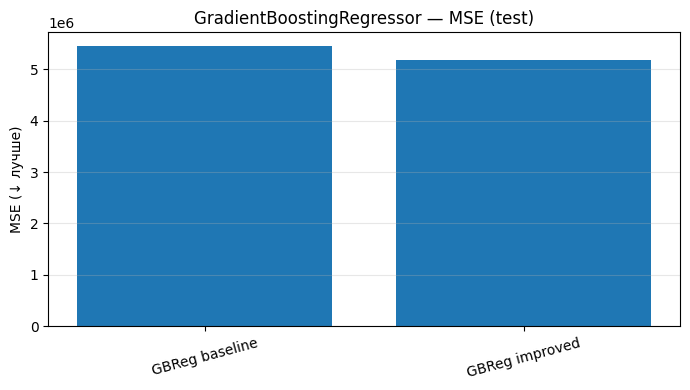

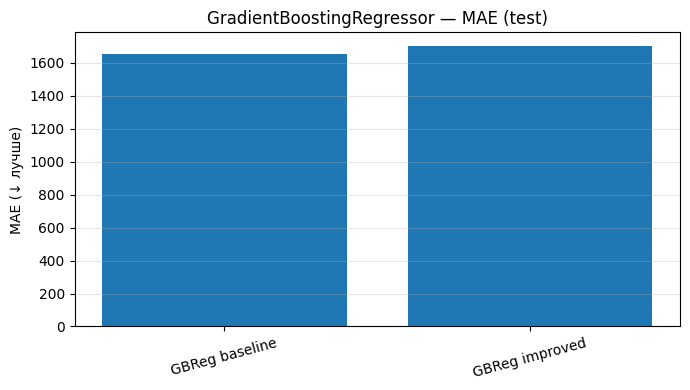

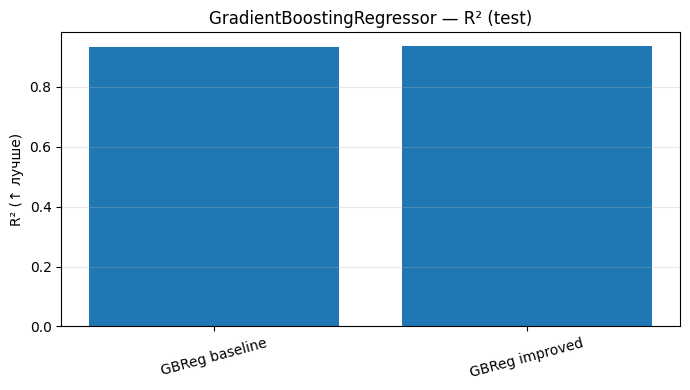

In [10]:
models_reg = ["GBReg baseline", "GBReg improved"]

mses = [mse_gb_base, mse_gb_imp]
maes = [mae_gb_base, mae_gb_imp]
r2s  = [r2_gb_base, r2_gb_imp]

plt.figure(figsize=(7, 4))
plt.bar(models_reg, mses)
plt.ylabel("MSE (↓ лучше)")
plt.title("GradientBoostingRegressor — MSE (test)")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(models_reg, maes)
plt.ylabel("MAE (↓ лучше)")
plt.title("GradientBoostingRegressor — MAE (test)")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(models_reg, r2s)
plt.ylabel("R² (↑ лучше)")
plt.title("GradientBoostingRegressor — R² (test)")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Своя реализация

Градиентный бустинг представляет собой ансамблевый метод машинного обучения, в котором модель строится как сумма слабых алгоритмов. На каждом шаге обучения новый алгоритм аппроксимирует отрицательный градиент функции потерь (остатки предыдущей модели), за счёт чего происходит последовательное уменьшение ошибки. В качестве базового алгоритма используется собственная реализация решающего дерева регрессии ограниченной глубины (MyDecisionTreeRegressor).

In [6]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin


class MyDecisionTreeRegressor:
    class Node:
        def __init__(self, feature_index=None, threshold=None,
                     left=None, right=None, value=None):
            self.feature_index = feature_index
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value

        def is_leaf(self):
            return self.value is not None

    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = None
        self.n_features_ = None

    def fit(self, X, y, sample_weight=None):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        n_samples = X.shape[0]
        if sample_weight is None:
            sample_weight = np.ones(n_samples, dtype=float)
        else:
            sample_weight = np.asarray(sample_weight, dtype=float)

        self.n_features_ = X.shape[1]
        self.root = self._build_tree(X, y, sample_weight, depth=0)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_row(x, self.root) for x in X])

    def _weighted_mse(self, y, w):
        if len(y) == 0:
            return 0.0
        w_sum = np.sum(w)
        if w_sum == 0.0:
            return 0.0
        mean = np.sum(w * y) / w_sum
        return np.sum(w * (y - mean) ** 2) / w_sum

    def _best_split(self, X, y, w):
        m, n = X.shape
        if m < self.min_samples_split:
            return None, None

        best_feature = None
        best_threshold = None
        best_impurity = float("inf")

        total_weight = np.sum(w)

        for feature in range(n):
            sorted_idx = np.argsort(X[:, feature])
            Xf = X[sorted_idx, feature]
            yf = y[sorted_idx]
            wf = w[sorted_idx]

            for i in range(1, m):
                if Xf[i] == Xf[i - 1]:
                    continue

                thr = 0.5 * (Xf[i] + Xf[i - 1])

                left_y = yf[:i]
                right_y = yf[i:]
                left_w = wf[:i]
                right_w = wf[i:]

                if len(left_y) < self.min_samples_leaf or len(right_y) < self.min_samples_leaf:
                    continue

                w_left = np.sum(left_w)
                w_right = np.sum(right_w)
                if w_left == 0.0 or w_right == 0.0:
                    continue

                mse_left = self._weighted_mse(left_y, left_w)
                mse_right = self._weighted_mse(right_y, right_w)

                impurity = (w_left * mse_left + w_right * mse_right) / total_weight

                if impurity < best_impurity:
                    best_impurity = impurity
                    best_feature = feature
                    best_threshold = thr

        return best_feature, best_threshold

    def _build_tree(self, X, y, w, depth):
        num_samples = len(y)

        if (self.max_depth is not None and depth >= self.max_depth) or \
           num_samples < self.min_samples_split:
            w_sum = np.sum(w)
            if w_sum == 0.0:
                leaf_value = float(np.mean(y))
            else:
                leaf_value = float(np.sum(w * y) / w_sum)
            return self.Node(value=leaf_value)

        feature, threshold = self._best_split(X, y, w)
        if feature is None:
            w_sum = np.sum(w)
            if w_sum == 0.0:
                leaf_value = float(np.mean(y))
            else:
                leaf_value = float(np.sum(w * y) / w_sum)
            return self.Node(value=leaf_value)

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        left_child = self._build_tree(X[left_mask], y[left_mask], w[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], w[right_mask], depth + 1)

        return self.Node(feature_index=feature,
                         threshold=threshold,
                         left=left_child,
                         right=right_child)

    def _predict_row(self, x, node):
        while not node.is_leaf():
            if x[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value

class MyGradientBoostingRegressor(BaseEstimator, RegressorMixin):

    def __init__(self,
                 n_estimators=100,
                 learning_rate=0.1,
                 max_depth=3,
                 min_samples_split=2,
                 min_samples_leaf=1,
                 random_state=None):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    def fit(self, X, y):
        if hasattr(X, "toarray"):
            X = X.toarray()
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        n_samples = X.shape[0]

        self.init_ = float(np.mean(y))
        self.estimators_ = []

        current_pred = np.full(n_samples, self.init_, dtype=float)

        for _ in range(self.n_estimators):
            residual = y - current_pred

            tree = MyDecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
            )
            tree.fit(X, residual)
            update = tree.predict(X)

            current_pred += self.learning_rate * update
            self.estimators_.append(tree)

        return self

    def predict(self, X):
        if hasattr(X, "toarray"):
            X = X.toarray()
        X = np.asarray(X, dtype=float)

        y_pred = np.full(X.shape[0], self.init_, dtype=float)
        for tree in self.estimators_:
            y_pred += self.learning_rate * tree.predict(X)
        return y_pred

class MyGradientBoostingClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self,
                 n_estimators=50,
                 learning_rate=0.1,
                 max_depth=3,
                 min_samples_split=2,
                 min_samples_leaf=1,
                 random_state=None):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    @staticmethod
    def _softmax(F):
        F = F - F.max(axis=1, keepdims=True)
        exp_F = np.exp(F)
        sums = exp_F.sum(axis=1, keepdims=True)
        return exp_F / sums

    def fit(self, X, y):
        if hasattr(X, "toarray"):
            X = X.toarray()
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        self.classes_, y_enc = np.unique(y, return_inverse=True)
        n_samples = X.shape[0]
        n_classes = len(self.classes_)

        Y = np.zeros((n_samples, n_classes), dtype=float)
        Y[np.arange(n_samples), y_enc] = 1.0

        self.estimators_ = []
        self.n_classes_ = n_classes

        class_counts = np.bincount(y_enc, minlength=n_classes)
        class_priors = class_counts / n_samples
        eps = 1e-12
        self.init_ = np.log(class_priors + eps)

        F = np.tile(self.init_, (n_samples, 1))

        class_weight = n_samples / (n_classes * (class_counts + eps))
        sample_weight = class_weight[y_enc]
        self.class_weight_ = class_weight
        self.sample_weight_ = sample_weight

        for _ in range(self.n_estimators):
            P = self._softmax(F)
            stage_estimators = []

            for k in range(n_classes):
                residual = Y[:, k] - P[:, k]

                tree = MyDecisionTreeRegressor(
                    max_depth=self.max_depth,
                    min_samples_split=self.min_samples_split,
                    min_samples_leaf=self.min_samples_leaf,
                )
                tree.fit(X, residual, sample_weight=sample_weight)
                update = tree.predict(X)

                F[:, k] += self.learning_rate * update
                stage_estimators.append(tree)

            self.estimators_.append(stage_estimators)

        return self

    def _raw_predict(self, X):
        if hasattr(X, "toarray"):
            X = X.toarray()
        X = np.asarray(X, dtype=float)

        n_samples = X.shape[0]
        n_classes = self.n_classes_

        F = np.tile(self.init_, (n_samples, 1))
        for stage_estimators in self.estimators_:
            for k in range(n_classes):
                tree = stage_estimators[k]
                F[:, k] += self.learning_rate * tree.predict(X)
        return F

    def predict_proba(self, X):
        F = self._raw_predict(X)
        return self._softmax(F)

    def predict(self, X):
        proba = self.predict_proba(X)
        indices = np.argmax(proba, axis=1)
        return self.classes_[indices]


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

my_gb_clf = Pipeline(steps=[
    ("preprocess", preprocess_cls),
    ("model", MyGradientBoostingClassifier(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=3,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=RANDOM_STATE
    ))
])

my_gb_clf.fit(X_train_cls, y_train_cls)
y_pred_my_gb_cls = my_gb_clf.predict(X_test_cls)

acc_my_gb_base = accuracy_score(y_test_cls, y_pred_my_gb_cls)
f1_my_gb_base = f1_score(y_test_cls, y_pred_my_gb_cls, average="macro")

print(f"[MyGB Classifier — default]  Acc={acc_my_gb_base:.4f} | F1-macro={f1_my_gb_base:.4f}")
print(classification_report(y_test_cls, y_pred_my_gb_cls))


[MyGB Classifier — default]  Acc=0.8815 | F1-macro=0.8900
              precision    recall  f1-score   support

         acc       0.66      0.95      0.78        77
        good       0.93      1.00      0.97        14
       unacc       1.00      0.85      0.92       242
       vgood       0.81      1.00      0.90        13

    accuracy                           0.88       346
   macro avg       0.85      0.95      0.89       346
weighted avg       0.92      0.88      0.89       346



In [8]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

cv_clf_my_gb = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

my_gb_clf_pipe = Pipeline(steps=[
    ("preprocess", preprocess_cls),
    ("model", MyGradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_grid_my_gb_clf = {
    "model__n_estimators": [50, 100],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

grid_my_gb_clf = GridSearchCV(
    my_gb_clf_pipe,
    param_grid_my_gb_clf,
    scoring="f1_macro",
    cv=cv_clf_my_gb,
    n_jobs=-1,
    verbose=1
)

grid_my_gb_clf.fit(X_train_cls, y_train_cls)

print("Best params (MyGB classifier):", grid_my_gb_clf.best_params_)
print("Best CV score (F1-macro):", grid_my_gb_clf.best_score_)

my_gb_clf_best = grid_my_gb_clf.best_estimator_
y_pred_my_gb_clf = my_gb_clf_best.predict(X_test_cls)

acc_my_gb = accuracy_score(y_test_cls, y_pred_my_gb_clf)
f1_my_gb = f1_score(y_test_cls, y_pred_my_gb_clf, average="macro")

print(f"[MyGradientBoostingClassifier — best]  Acc={acc_my_gb:.4f} | F1-macro={f1_my_gb:.4f}")


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params (MyGB classifier): {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV score (F1-macro): 0.7869338960958184
[MyGradientBoostingClassifier — best]  Acc=0.8671 | F1-macro=0.8461


In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

my_gb_reg = Pipeline(steps=[
    ("preprocess", preprocess_reg),
    ("model", MyGradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=RANDOM_STATE
    ))
])

my_gb_reg.fit(X_train_reg, y_train_reg)
y_pred_my_gb_reg_base = my_gb_reg.predict(X_test_reg)

mse_my_gb_base = mean_squared_error(y_test_reg, y_pred_my_gb_reg_base)
mae_my_gb_base = mean_absolute_error(y_test_reg, y_pred_my_gb_reg_base)
r2_my_gb_base = r2_score(y_test_reg, y_pred_my_gb_reg_base)

print(f"[MyGB Regressor — default]  MSE={mse_my_gb_base:.2f} | MAE={mae_my_gb_base:.2f} | R²={r2_my_gb_base:.4f}")


[MyGB Regressor — default]  MSE=5399348.78 | MAE=1652.32 | R²=0.9316


In [10]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

cv_reg_my_gb = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

my_gb_reg_pipe = Pipeline(steps=[
    ("preprocess", preprocess_reg),
    ("model", MyGradientBoostingRegressor(random_state=RANDOM_STATE))
])

param_grid_my_gb_reg = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

grid_my_gb_reg = GridSearchCV(
    my_gb_reg_pipe,
    param_grid_my_gb_reg,
    scoring="neg_mean_squared_error",
    cv=cv_reg_my_gb,
    n_jobs=-1,
    verbose=1
)

grid_my_gb_reg.fit(X_train_reg, y_train_reg)

print("Best params (MyGB regressor):", grid_my_gb_reg.best_params_)
print("Best CV score (neg MSE):", grid_my_gb_reg.best_score_)

my_gb_reg_best = grid_my_gb_reg.best_estimator_
y_pred_my_gb_reg = my_gb_reg_best.predict(X_test_reg)

mse_my_gb = mean_squared_error(y_test_reg, y_pred_my_gb_reg)
mae_my_gb = mean_absolute_error(y_test_reg, y_pred_my_gb_reg)
r2_my_gb = r2_score(y_test_reg, y_pred_my_gb_reg)

print(f"[MyGradientBoostingRegressor — best]  MSE={mse_my_gb:.2f} | MAE={mae_my_gb:.2f} | R²={r2_my_gb:.4f}")


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best params (MyGB regressor): {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV score (neg MSE): -5478352.411052656
[MyGradientBoostingRegressor — best]  MSE=5641830.67 | MAE=1806.10 | R²=0.9285


## Графики

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models_cls = {
  #  "SkGB baseline":  (acc_gb_base, f1_gb_base),
  #  "SkGB improved":  (acc_gb_imp,  f1_gb_imp),
    "MyGB baseline":  (acc_my_gb_base,   f1_my_gb_base),
    "MyGB tuned":     (acc_my_gb, f1_my_gb)
}

rows = []
for name, (acc, f1) in models_cls.items():
    rows.append({"Model": name, "Accuracy": acc, "F1-macro": f1})

df_cls = pd.DataFrame(rows)
print(df_cls.sort_values("F1-macro", ascending=False))


           Model  Accuracy  F1-macro
0  MyGB baseline  0.881503  0.890011
1     MyGB tuned  0.867052  0.846140


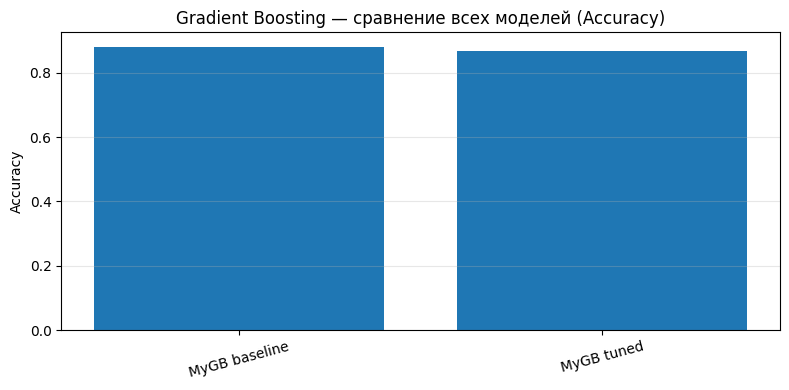

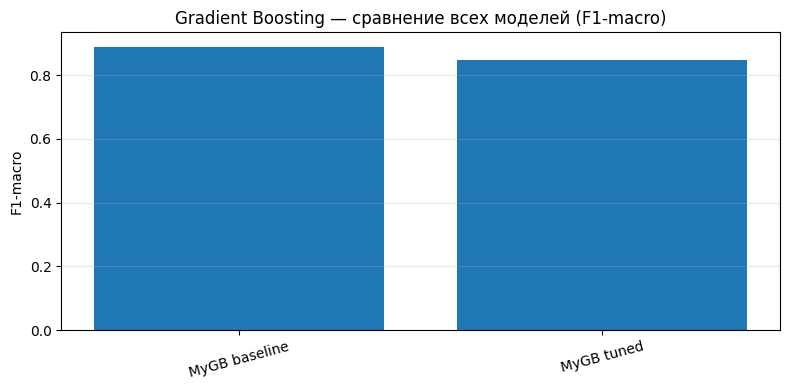

In [13]:
plt.figure(figsize=(8, 4))
plt.bar(df_cls["Model"], df_cls["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Gradient Boosting — сравнение всех моделей (Accuracy)")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(df_cls["Model"], df_cls["F1-macro"])
plt.ylabel("F1-macro")
plt.title("Gradient Boosting — сравнение всех моделей (F1-macro)")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def reg_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2


models_reg = {
 #   "SkGBReg baseline": y_pred_gb_base_reg,
 #   "SkGBReg improved": y_pred_gb_imp_reg,
    "MyGBReg baseline": y_pred_my_gb_reg_base,
    "MyGBReg tuned":    y_pred_my_gb_reg
}

rows = []
for name, y_hat in models_reg.items():
    mse, rmse, mae, r2 = reg_metrics(y_test_reg, y_hat)
    rows.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2
    })

df_reg = pd.DataFrame(rows)
print(df_reg.sort_values("RMSE"))


              Model           MSE         RMSE          MAE        R²
0  MyGBReg baseline  5.399349e+06  2323.649884  1652.316683  0.931605
1     MyGBReg tuned  5.641831e+06  2375.253811  1806.095126  0.928534


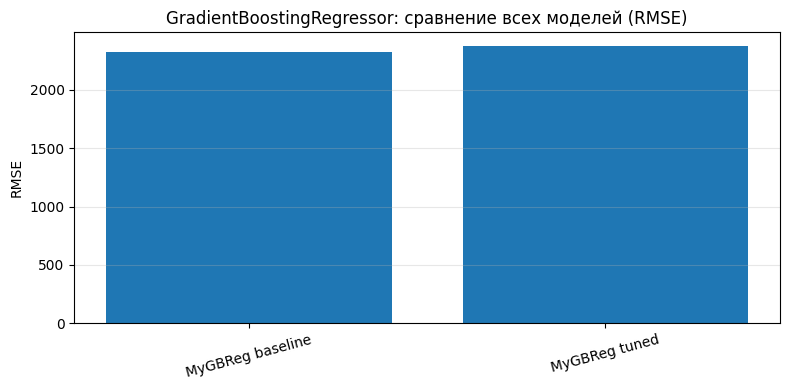

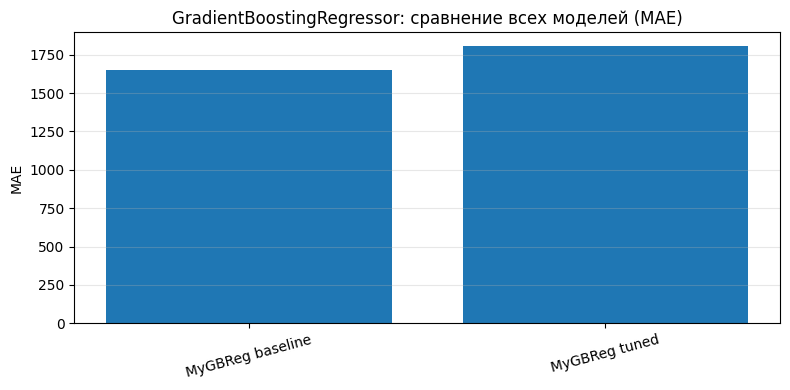

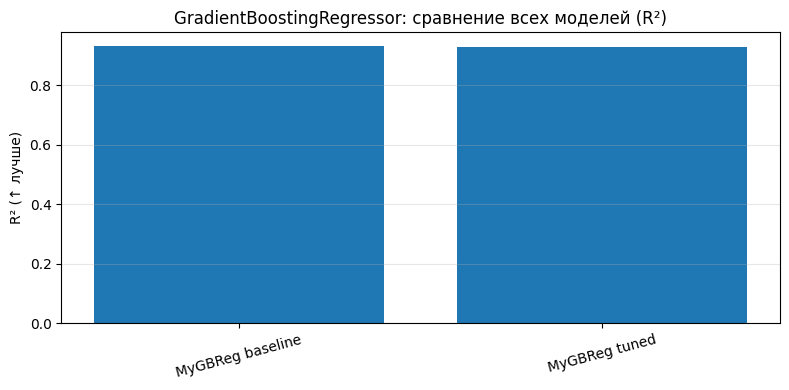

In [15]:
plt.figure(figsize=(8, 4))
plt.bar(df_reg["Model"], df_reg["RMSE"])
plt.ylabel("RMSE")
plt.title("GradientBoostingRegressor: сравнение всех моделей (RMSE)")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(df_reg["Model"], df_reg["MAE"])
plt.ylabel("MAE")
plt.title("GradientBoostingRegressor: сравнение всех моделей (MAE)")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(df_reg["Model"], df_reg["R²"])
plt.ylabel("R² (↑ лучше)")
plt.title("GradientBoostingRegressor: сравнение всех моделей (R²)")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
